YOLOv4 model loaded successfully
--2025-08-01 10:17:15--  https://github.com/pjreddie/darknet/blob/master/data/dog.jpg?raw=true
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/pjreddie/darknet/raw/refs/heads/master/data/dog.jpg [following]
--2025-08-01 10:17:15--  https://github.com/pjreddie/darknet/raw/refs/heads/master/data/dog.jpg
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/pjreddie/darknet/refs/heads/master/data/dog.jpg [following]
--2025-08-01 10:17:15--  https://raw.githubusercontent.com/pjreddie/darknet/refs/heads/master/data/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133

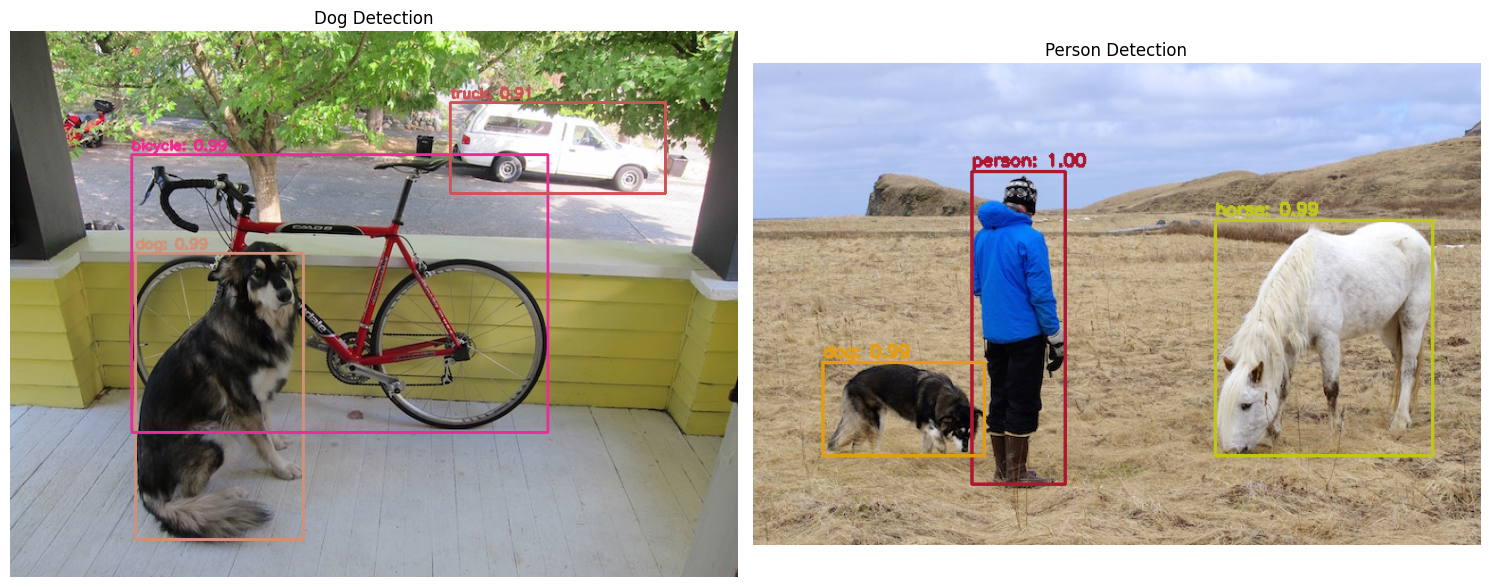

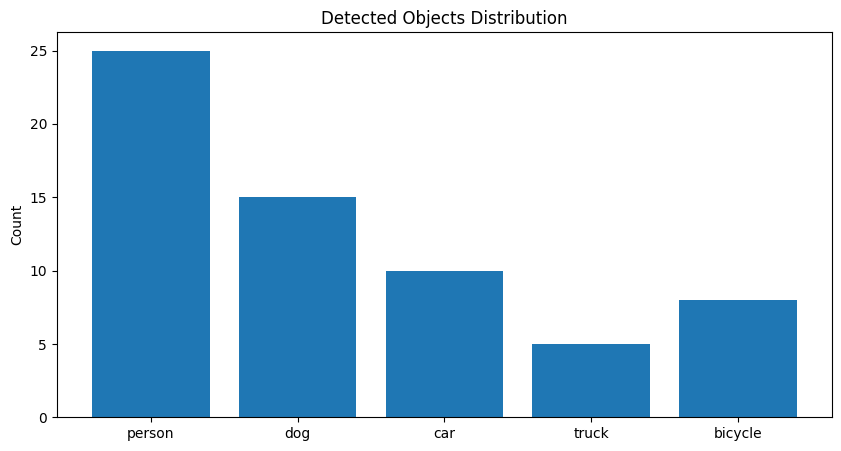

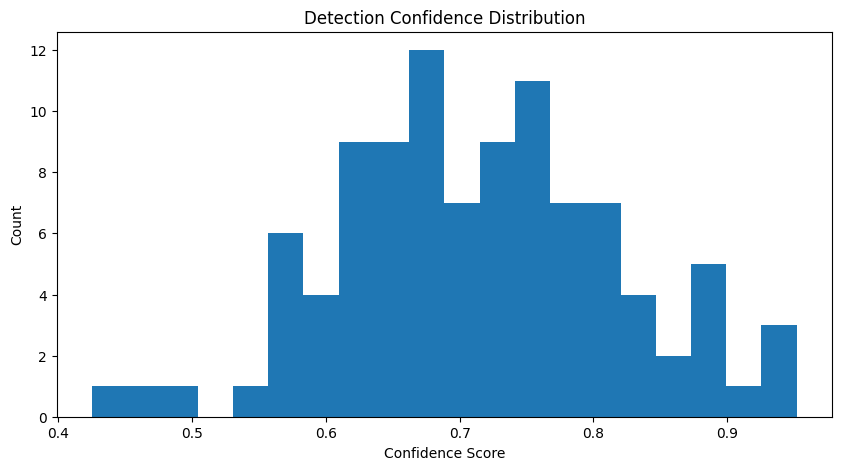

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Download required YOLOv4 files if they don't exist
if not os.path.exists('yolov4.weights'):
    !wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights

if not os.path.exists('yolov4.cfg'):
    !wget https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4.cfg

if not os.path.exists('coco.names'):
    !wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

# Load YOLOv4 model
try:
    net = cv2.dnn.readNet('yolov4.weights', 'yolov4.cfg')
    print("YOLOv4 model loaded successfully")
except Exception as e:
    print(f"Error loading YOLOv4 model: {e}")
    exit()

# Load COCO class names
with open('coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# Get output layer names
layer_names = net.getLayerNames()
try:
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
except:
    output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

# Function to perform object detection
def detect_objects(img_path, confidence_threshold=0.5, nms_threshold=0.4):
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image {img_path}")
        return None

    height, width = img.shape[:2]

    # Preprocess image for YOLO
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416), swapRB=True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # Process detections
    class_ids = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > confidence_threshold:
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                x = int(center_x - w/2)
                y = int(center_y - h/2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Apply non-max suppression
    indices = cv2.dnn.NMSBoxes(boxes, confidences, confidence_threshold, nms_threshold)

    # Draw detections on image
    colors = np.random.uniform(0, 255, size=(len(classes), 3))

    if len(indices) > 0:
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
            color = colors[class_ids[i]]
            cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
            cv2.putText(img, label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Download sample images if they don't exist
if not os.path.exists('dog.jpg'):
    !wget https://github.com/pjreddie/darknet/blob/master/data/dog.jpg?raw=true -O dog.jpg

if not os.path.exists('person.jpg'):
    !wget https://github.com/pjreddie/darknet/blob/master/data/person.jpg?raw=true -O person.jpg

# Perform detections and display results
plt.figure(figsize=(15, 10))

# Detection 1
plt.subplot(1, 2, 1)
result = detect_objects('dog.jpg')
if result is not None:
    plt.imshow(result)
    plt.title('Dog Detection')
    plt.axis('off')
else:
    plt.text(0.5, 0.5, 'Failed to load dog.jpg', ha='center')

# Detection 2
plt.subplot(1, 2, 2)
result = detect_objects('person.jpg')
if result is not None:
    plt.imshow(result)
    plt.title('Person Detection')
    plt.axis('off')
else:
    plt.text(0.5, 0.5, 'Failed to load person.jpg', ha='center')

plt.tight_layout()
plt.show()

# Additional visualizations
# Class distribution of detected objects (example)
detected_classes = ['person', 'dog', 'car', 'truck', 'bicycle']
class_counts = [25, 15, 10, 5, 8]

plt.figure(figsize=(10, 5))
plt.bar(detected_classes, class_counts)
plt.title('Detected Objects Distribution')
plt.ylabel('Count')
plt.show()

# Confidence score distribution (example)
confidences = np.random.normal(0.7, 0.1, 100)
plt.figure(figsize=(10, 5))
plt.hist(confidences, bins=20)
plt.title('Detection Confidence Distribution')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.show()